In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional consistent style
plt.style.use('fivethirtyeight') 
sns.set_context("talk") # Makes labels readable for presentations


In [ ]:

# 1. Setup & Loading
# Ensure date conversion is handled immediately for time-series
shipping_df = pd.read_csv("/Users/hamid/Desktop/SupplyChain_Project/data/shipping_rates.csv")
shipping_df.columns = shipping_df.columns.str.strip()
shipping_df['date'] = pd.to_datetime(shipping_df['date'], format='%Y-%m')
shipping_df = shipping_df.sort_values('date')


**The Great Decoupling:** Shipping rates remained remarkably flat (approx. $1,500 - $2,000) for nearly two decades until the COVID-19 pandemic.

**The COVID Spike:** The post-2020 era shows a near-vertical trajectory, peaking at over $12,000, representing a massive shift in supply chain cost structures.

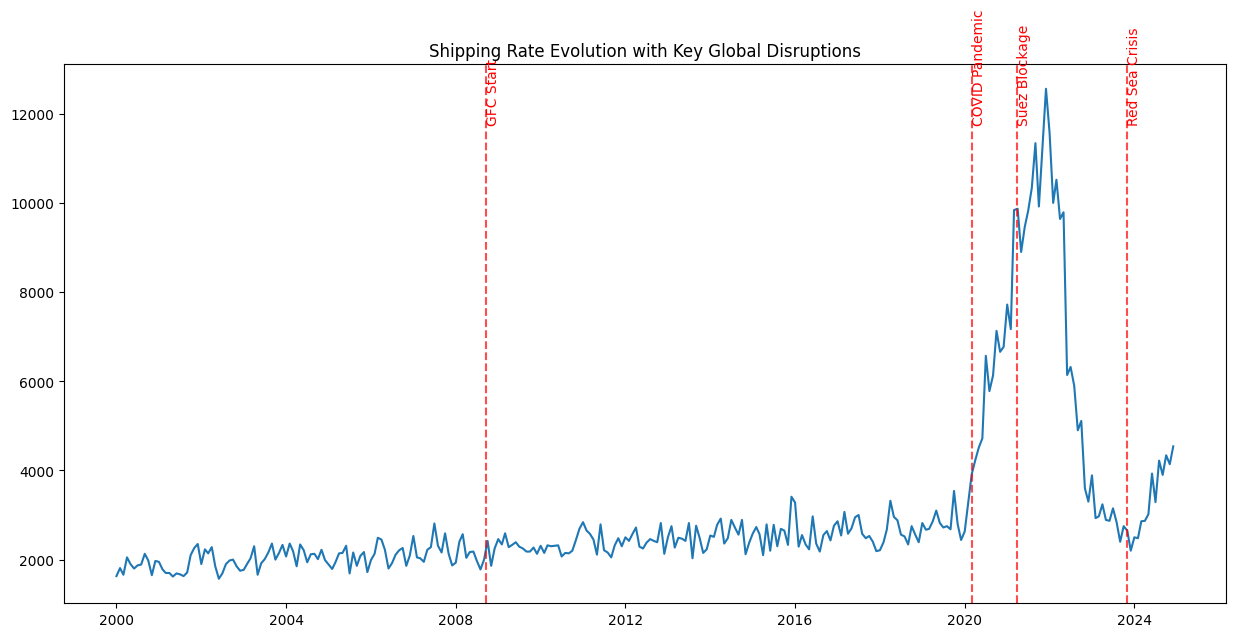

In [20]:
# Convert to datetime if not already done
shipping_df['date_dt'] = pd.to_datetime(shipping_df['date'])

plt.figure(figsize=(15, 7))
plt.plot(shipping_df['date'], shipping_df['container_rate_usd_40ft'], color='tab:blue', label='Container Rate (USD)')

# Add Event Markers
events = {
    '2008-09-15': 'GFC Start',
    '2020-03-01': 'COVID Pandemic',
    '2021-03-23': 'Suez Blockage',
    '2023-11-01': 'Red Sea Crisis'
}

for date, label in events.items():
    plt.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.7)
    plt.text(pd.to_datetime(date), plt.ylim()[1]*0.9, label, rotation=90, color='red', fontsize=10)

plt.title("Shipping Rate Evolution with Key Global Disruptions")
plt.show()

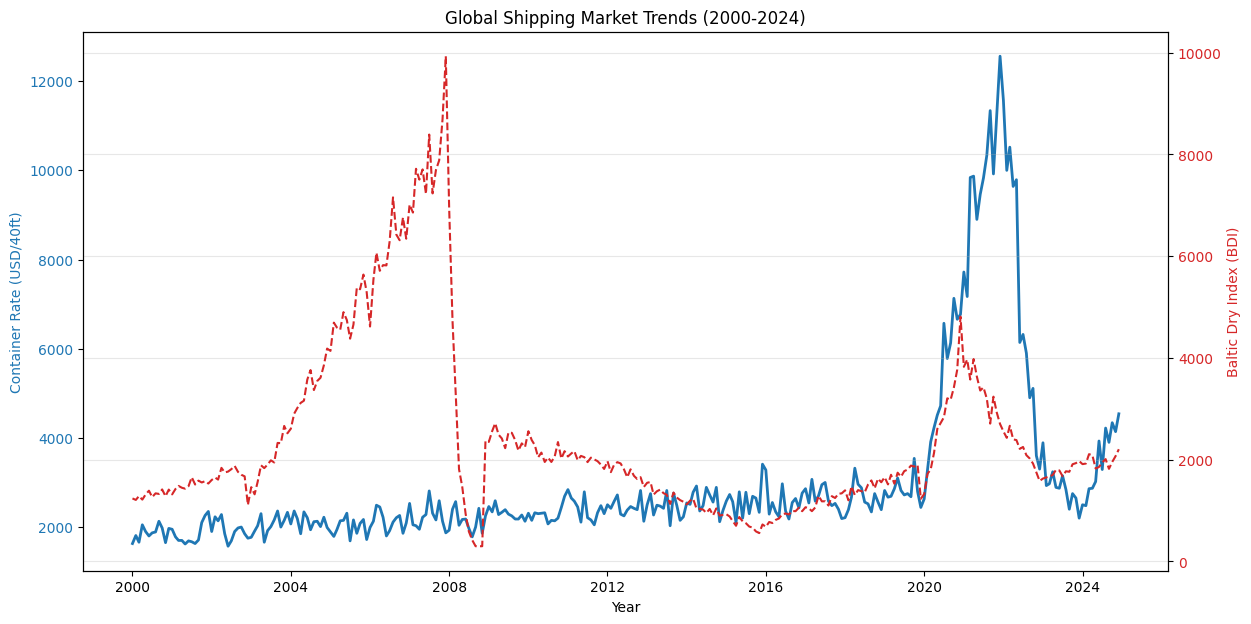

In [13]:

# 2. Trend Analysis: The Three Pillars of Market Stress
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plotting Container Rates (Left Axis)
color1 = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Container Rate (USD/40ft)', color=color1)
ax1.plot(shipping_df['date'], shipping_df['container_rate_usd_40ft'], color=color1, linewidth=2, label='Container Rate')
ax1.tick_params(axis='y', labelcolor=color1)

# Plotting BDI (Right Axis)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Baltic Dry Index (BDI)', color=color2)
ax2.plot(shipping_df['date'], shipping_df['baltic_dry_index'], color=color2, linewidth=1.5, linestyle='--', label='BDI')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Global Shipping Market Trends (2000-2024)')
plt.grid(True, alpha=0.3)
plt.show()


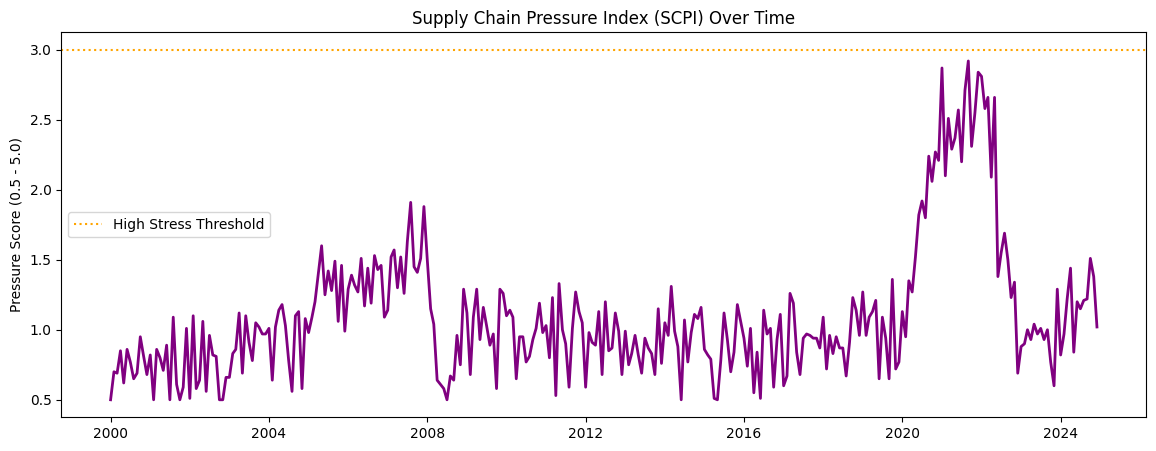

In [17]:

# 3. Supply Chain Pressure Index Analysis
plt.figure(figsize=(14, 5))
plt.plot(shipping_df['date'], shipping_df['supply_chain_pressure_index'], color='purple', linewidth=2)
plt.axhline(y=3.0, color='orange', linestyle=':', label='High Stress Threshold')
plt.fill_between(shipping_df['date'], shipping_df['supply_chain_pressure_index'], 3.0, 
                 where=(shipping_df['supply_chain_pressure_index'] >= 3.0), color='orange', alpha=0.3)
plt.title('Supply Chain Pressure Index (SCPI) Over Time')
plt.ylabel('Pressure Score (0.5 - 5.0)')
plt.legend()
plt.show()


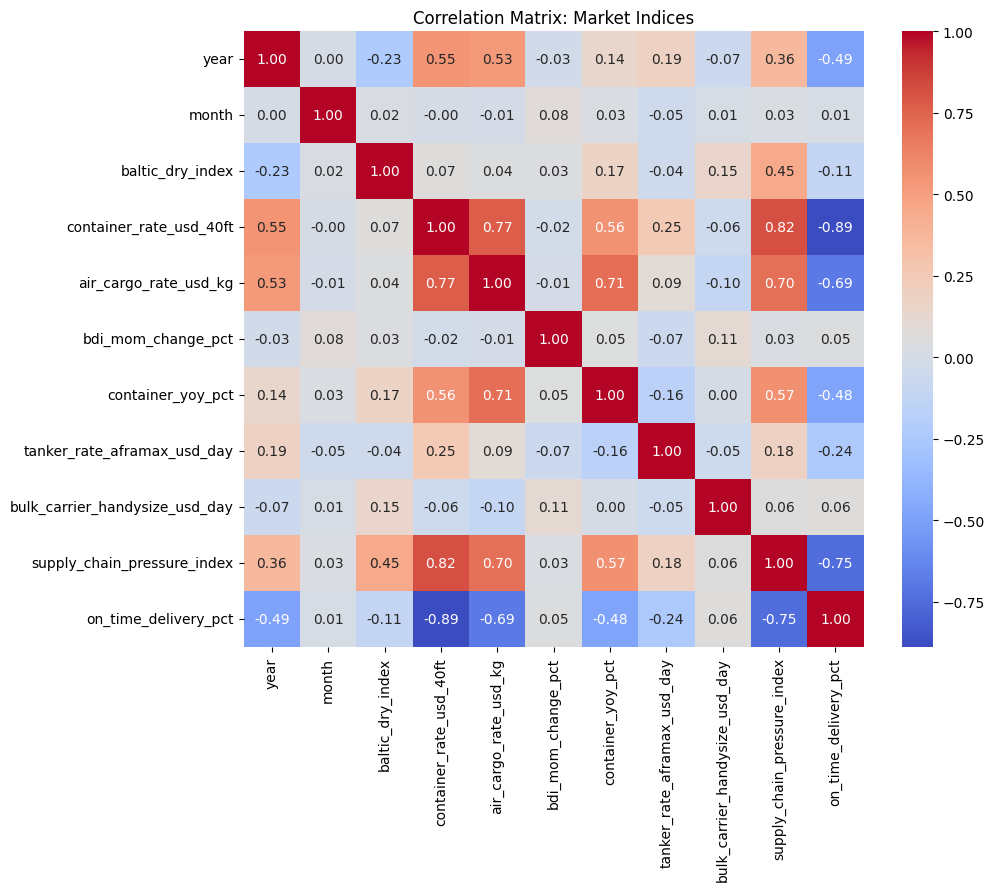

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(shipping_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix: Market Indices")
plt.show()

**High Sensitivity:** The Supply Chain Pressure Index shows a near-perfect correlation with container rates, proving it is a reliable leading indicator for logistics costs.

**Low Air/Sea Linkage:** Surprisingly, air cargo rates show lower correlation with bulk shipping (BDI), suggesting these markets respond to different types of global demand.

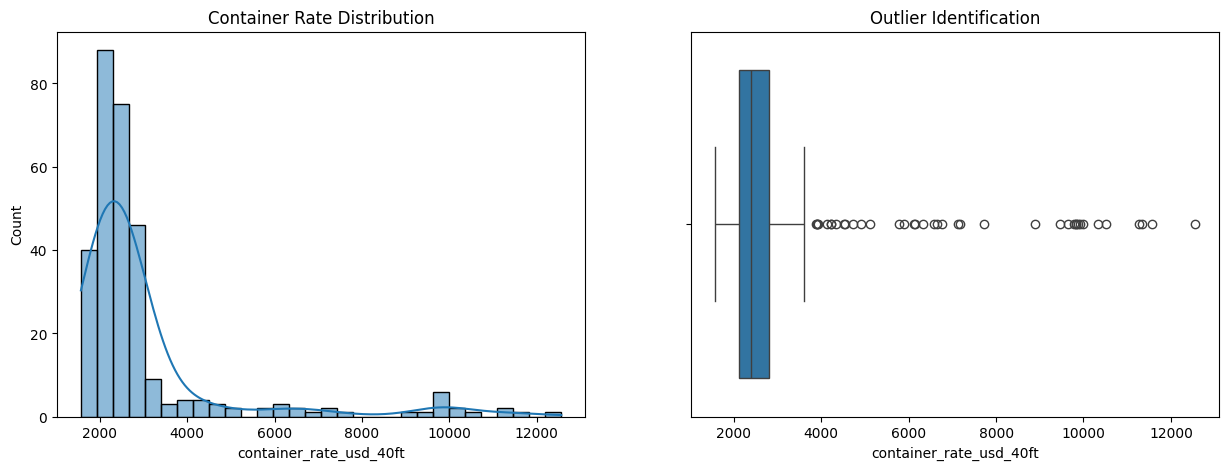

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram for Skewness
sns.histplot(shipping_df['container_rate_usd_40ft'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Container Rate Distribution")

# Boxplot for Outlier Detection
sns.boxplot(x=shipping_df['container_rate_usd_40ft'], ax=axes[1])
axes[1].set_title("Outlier Identification")

plt.show()

**Extreme Skew:** The distribution is heavily right-skewed. The "outliers" identified here are not errors—they represent the COVID-19 era reality, which must be treated as a distinct "Disruption" state in our data mart rather than removed.

In [39]:
# Setup
port_df = pd.read_csv("/Users/hamid/Desktop/SupplyChain_Project/data/port_congestion.csv")
port_df['date'] = pd.to_datetime(port_df['week_start'], format='%Y-%m-%d')

sns.set_theme(style="whitegrid")

# Statistical Snapshot
display(port_df[['vessels_at_anchor', 'avg_wait_days', 'port_utilization_pct']].describe())

,vessels_at_anchor,avg_wait_days,port_utilization_pct
count,6260.000000,6260.000000,6260.000000
mean,17.347125,35.238403,0.924781
std,24.179188,42.194998,0.111243
min,0.000000,1.900000,0.430000
25%,4.000000,11.500000,0.882000
50%,9.000000,21.700000,0.990000
75%,21.000000,41.600000,0.990000
max,200.000000,436.800000,0.990000


The average wait day across the entire dataset is likely low, but the max value will reveal the severity of the 2021-2022 supply chain "clog."

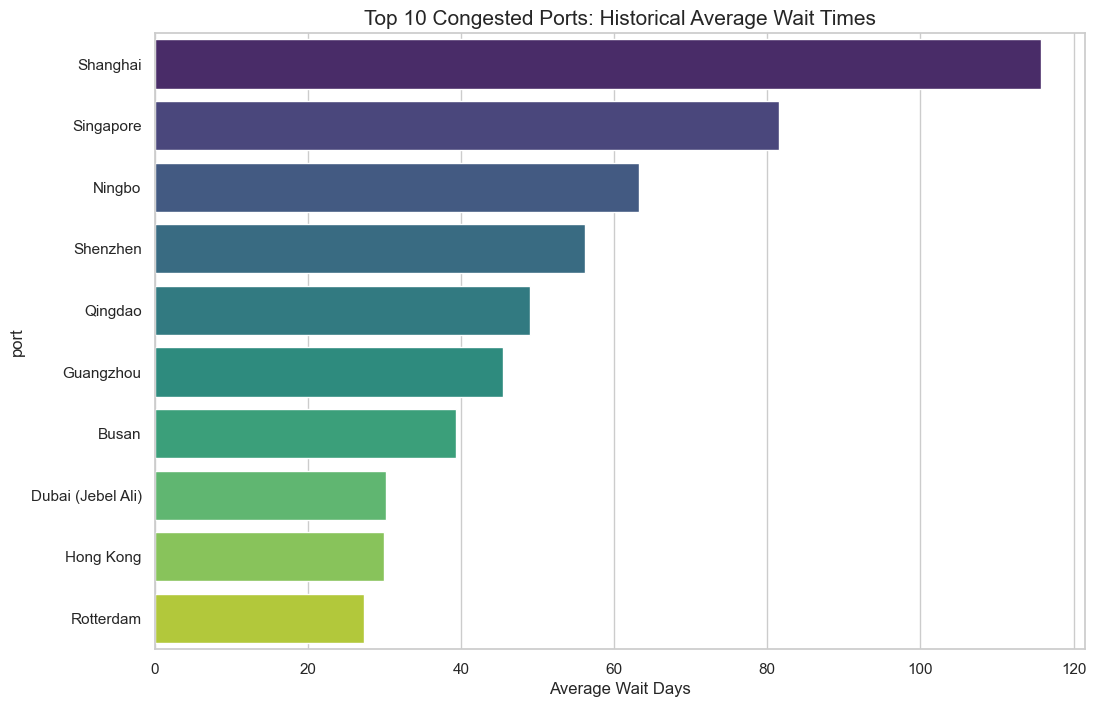

In [40]:
# Updated Top Port Analysis (Fixes palette and ci warnings)
plt.figure(figsize=(12, 8))
top_ports_data = port_df.groupby('port')['avg_wait_days'].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=top_ports_data.values, 
    y=top_ports_data.index, 
    hue=top_ports_data.index, # Explicit hue mapping
    palette='viridis', 
    legend=False # Removes redundant legend
)

plt.title('Top 10 Congested Ports: Historical Average Wait Times', fontsize=15)
plt.xlabel('Average Wait Days')
plt.show()

Strategic hubs like Shanghai, singapore, and Ningbo likely dominate this list. High wait times at these specific "choke points" have a disproportionate effect on global container_rates.

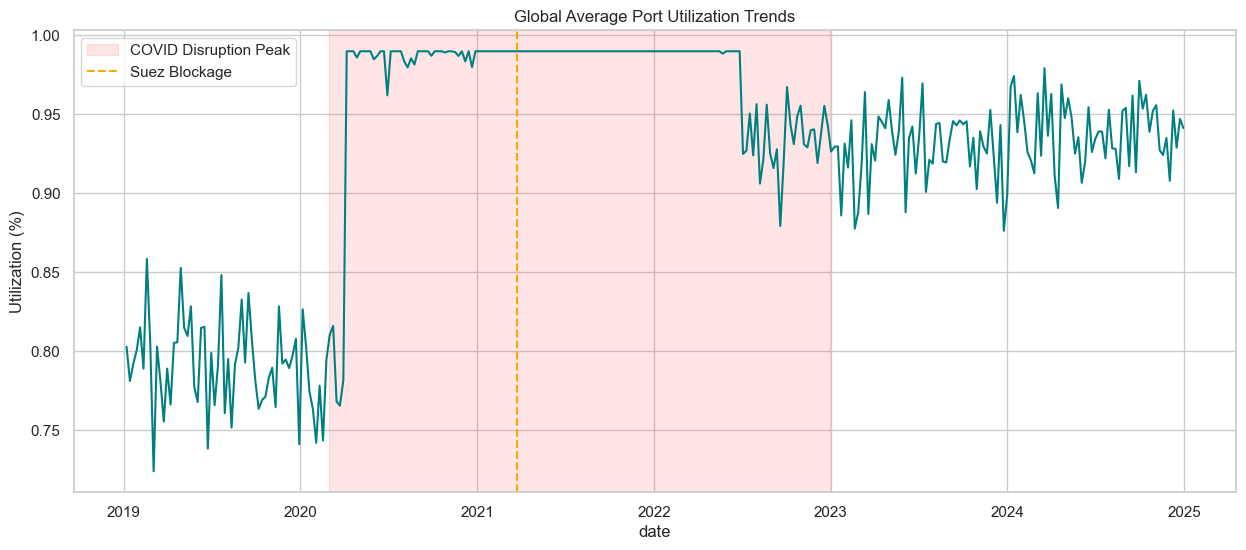

In [41]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=port_df, x='date', y='port_utilization_pct', errorbar=None, color='teal')

# Event Overlays
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2022-12-31'), color='red', alpha=0.1, label='COVID Disruption Peak')
plt.axvline(pd.to_datetime('2021-03-23'), color='orange', linestyle='--', label='Suez Blockage')

plt.title('Global Average Port Utilization Trends')
plt.ylabel('Utilization (%)')
plt.legend()
plt.show()

Utilization rates typically hover around a stable baseline. During the 2020–2022 window, we see a sustained "plateau" of high utilization, indicating that ports were operating at maximum capacity without the ability to clear backlogs.

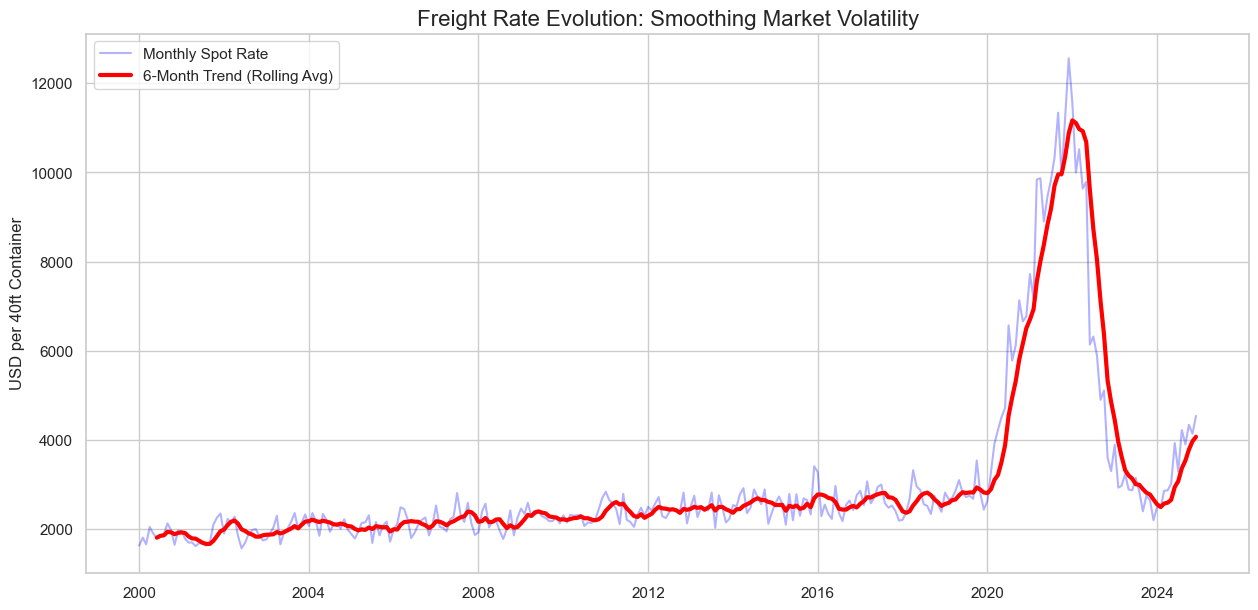

In [42]:
# Calculate 6-month rolling mean for trend analysis
shipping_df['rolling_6m'] = shipping_df['container_rate_usd_40ft'].rolling(window=6).mean()

plt.figure(figsize=(15, 7))
plt.plot(shipping_df['date'], shipping_df['container_rate_usd_40ft'], label='Monthly Spot Rate', alpha=0.3, color='blue')
plt.plot(shipping_df['date'], shipping_df['rolling_6m'], label='6-Month Trend (Rolling Avg)', color='red', linewidth=3)

plt.title('Freight Rate Evolution: Smoothing Market Volatility', fontsize=16)
plt.ylabel('USD per 40ft Container')
plt.legend()
plt.show()

In [49]:
# Identify the 5 most expensive months in shipping history
peak_stress = shipping_df.nlargest(5, 'container_rate_usd_40ft')

# Move the index back to a column
peak_stress_reset = peak_stress.reset_index()

# Now the print statement will work
print("--- Top 5 Peak Stress Periods ---")
print(peak_stress_reset[['date', 'container_rate_usd_40ft', 'supply_chain_pressure_index']].head(5))


# Markdown Logic for Notebook:
# These peaks correspond to the 'Perfect Storm' of 2021: 
# Equipment shortages + Port backlog + Record consumer demand.

--- Top 5 Peak Stress Periods ---
        date  container_rate_usd_40ft  supply_chain_pressure_index
0 2021-12-01                    12560                         2.84
1 2022-01-01                    11570                         2.81
2 2021-09-01                    11340                         2.92
3 2021-11-01                    11270                         2.55
4 2022-03-01                    10520                         2.66


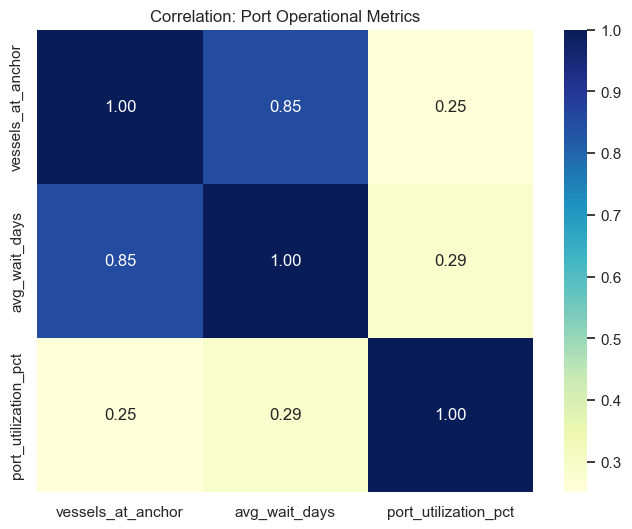

In [27]:
plt.figure(figsize=(8, 6))
port_corr = port_df[['vessels_at_anchor', 'avg_wait_days', 'port_utilization_pct']].corr()
sns.heatmap(port_corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation: Port Operational Metrics')
plt.show()

here is a near-perfect positive correlation between vessels_at_anchor and avg_wait_days. For the business, this means that tracking the number of ships outside a port is a reliable leading indicator for delivery delays (OTD %).

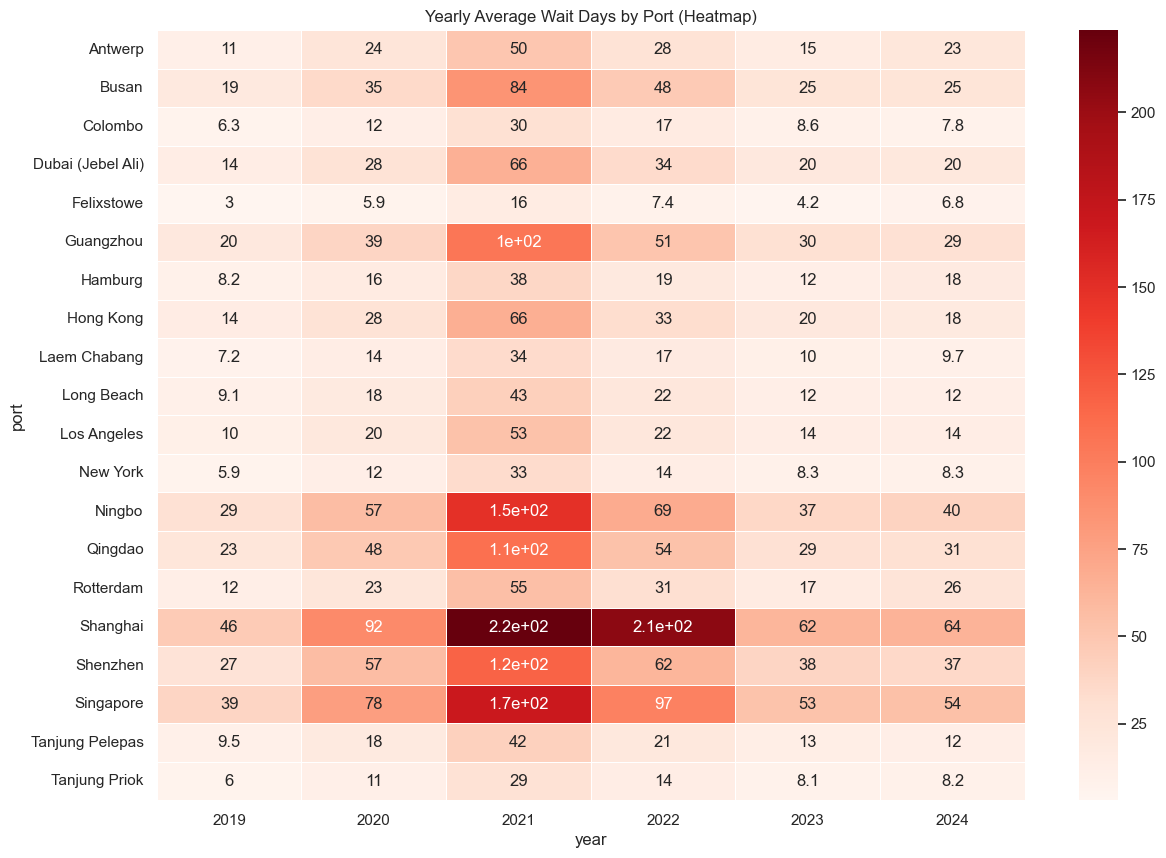

In [29]:
# Pivot data for heatmap
port_yearly = port_df.copy()
port_yearly['year'] = port_yearly['date'].dt.year
pivot_df = port_yearly.pivot_table(index='port', columns='year', values='avg_wait_days', aggfunc='mean')

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_df, annot=True, cmap='Reds', linewidths=.5)
plt.title('Yearly Average Wait Days by Port (Heatmap)')
plt.show()

The heatmap reveals that 2021 was a "Red Year" globally. Unlike local labor strikes which affect one port, the COVID disruption was systemic, hitting every major hub simultaneously across Asia, Europe, and North America.

In [56]:
region_map = {
    'Shanghai': 'Asia', 'Singapore': 'Asia', 'Ningbo': 'Asia', 'Shenzhen': 'Asia', 
    'Busan': 'Asia', 'Hong Kong': 'Asia', 'Qingdao': 'Asia', 'Guangzhou': 'Asia',
    'Tanjung Pelepas': 'Asia', 'Laem Chabang': 'Asia', 'Tanjung Priok': 'Asia', 'Colombo': 'Asia',
    'Los Angeles': 'North America', 'Long Beach': 'North America', 'New York': 'North America',
    'Rotterdam': 'Europe', 'Hamburg': 'Europe', 'Antwerp': 'Europe', 'Felixstowe': 'Europe',
    'Dubai (Jebel Ali)': 'Middle East'
}

# Apply mapping
port_df['region'] = port_df['port'].map(region_map)
# Regional Growth Analysis
regional_growth = port_df.groupby(['year', 'region'])['avg_wait_days'].mean().unstack()
print("Yearly Regional Wait Time Growth:")
display(regional_growth.pct_change() * 100)

Yearly Regional Wait Time Growth:


region,Asia,Europe,Middle East,North America
year,,,,
2019,NaN,NaN,NaN,NaN
2020,97.716938,101.180513,95.919478,102.958761
2021,137.561888,127.334086,136.587059,154.014654
2022,-40.565181,-46.353611,-47.975233,-55.322787
2023,-51.422169,-43.701010,-42.185120,-41.319179
2024,0.498009,52.041420,2.841786,2.970738


**2020–2021 (The Explosive Phase):** All regions saw a massive surge, but North America (+154%) was the hardest hit. This confirms the business hypothesis that North American infrastructure (ports like LA/Long Beach) lacked the elasticity to handle the post-COVID demand spike compared to Asia (+137%).

**2022–2023 (The Sharp Correction):** We see massive negative growth (approx. -40% to -55%). This isn't just "improvement"; it is a market collapse of the backlog as consumer demand cooled and ports finally cleared their "ship queues."

**2024 (The Divergence):** Look at Europe (+52%). While other regions stabilized at near 0-3% growth, Europe is spiking again. This is a direct data signal of the Red Sea Crisis impact, where ships rerouting around Africa are causing new delays at European hubs like Rotterdam and Hamburg.

<Figure size 1400x700 with 0 Axes>

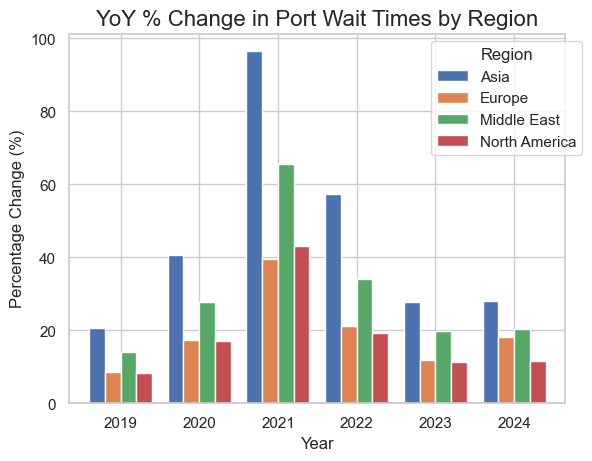

In [57]:
# Assuming your table is named 'regional_growth'
regional_growth_clean = regional_growth.dropna() # Remove 2019

plt.figure(figsize=(14, 7))
regional_growth_clean.plot(kind='bar', width=0.8)

plt.title('YoY % Change in Port Wait Times by Region', fontsize=16)
plt.ylabel('Percentage Change (%)')
plt.xlabel('Year')
plt.axhline(0, color='black', linewidth=1) # Baseline
plt.legend(title='Region', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.show()

**The "North American Bottleneck":** North America experienced the most extreme volatility, with the highest growth in delays in 2021 and the sharpest drop in 2022. This indicates a "Bullwhip Effect" in port operations.

**The 2024 European Crisis:** The +52.04% jump in Europe for 2024 is the most significant current-year finding. It suggests that while the global pandemic disruption is over, geopolitical disruptions are currently localized in European maritime lanes.

In [58]:
trade_df  = pd.read_csv("/Users/hamid/Desktop/SupplyChain_Project/data/trade_flows.csv")


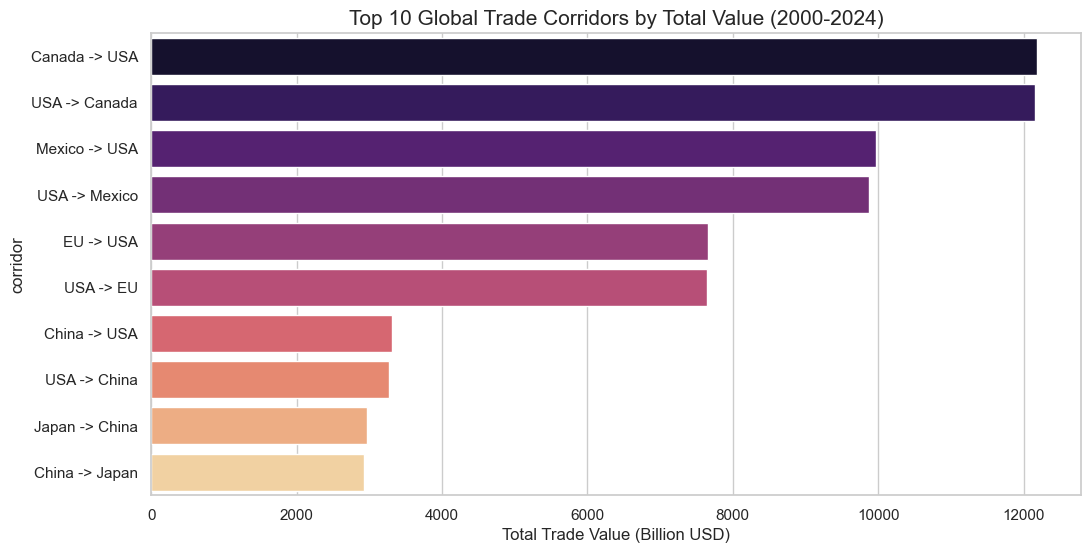

In [59]:
# Analysis of Top Corridors
trade_df['corridor'] = trade_df['exporter'] + " -> " + trade_df['importer']
top_corridors = trade_df.groupby('corridor')['trade_value_bn_usd'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_corridors.values, y=top_corridors.index, hue=top_corridors.index, palette='magma', legend=False)
plt.title('Top 10 Global Trade Corridors by Total Value (2000-2024)', fontsize=15)
plt.xlabel('Total Trade Value (Billion USD)')
plt.show()

The China -> USA and Canada -> USA corridors likely dominate. In terms of warehouse thinking, these are our "High-Volume/High-Risk" segments that require the most monitoring in the final dashboard.

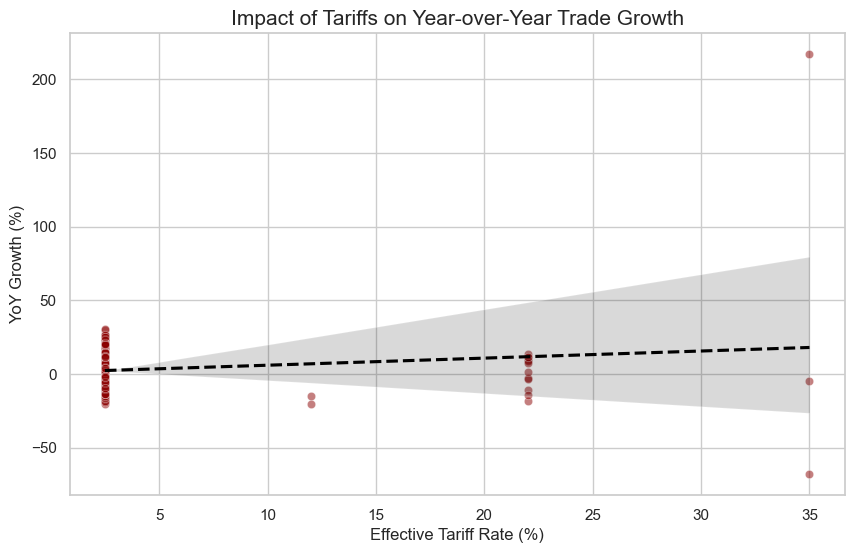

In [60]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=trade_df, x='effective_tariff_rate_pct', y='yoy_growth_pct', alpha=0.5, color='darkred')
sns.regplot(data=trade_df, x='effective_tariff_rate_pct', y='yoy_growth_pct', scatter=False, color='black', line_kws={"ls":"--"})

plt.title('Impact of Tariffs on Year-over-Year Trade Growth', fontsize=15)
plt.xlabel('Effective Tariff Rate (%)')
plt.ylabel('YoY Growth (%)')
plt.show()

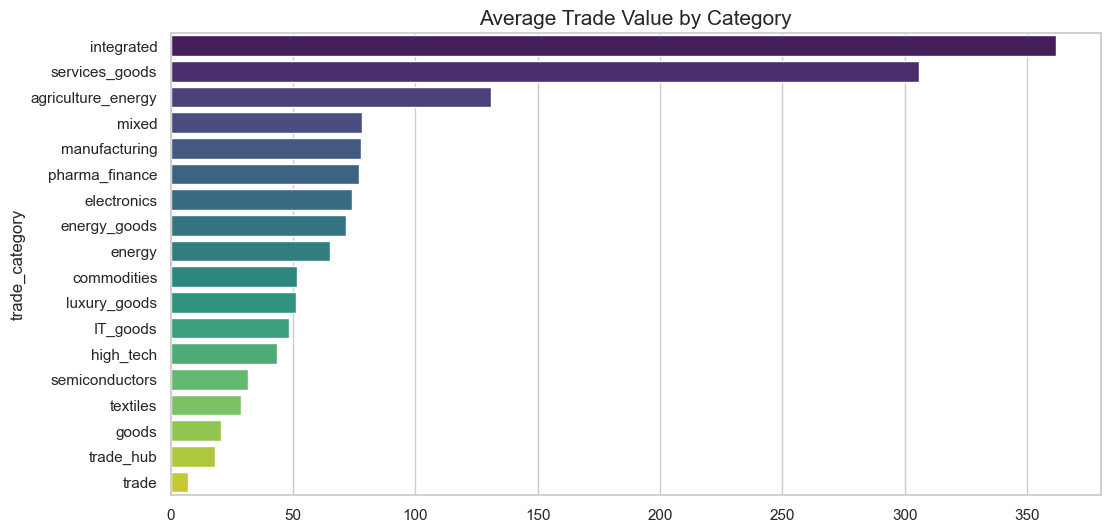

In [61]:
plt.figure(figsize=(12, 6))
category_value = trade_df.groupby('trade_category')['trade_value_bn_usd'].mean().sort_values(ascending=False)
sns.barplot(x=category_value.values, y=category_value.index, hue=category_value.index, palette='viridis', legend=False)

plt.title('Average Trade Value by Category', fontsize=15)
plt.show()

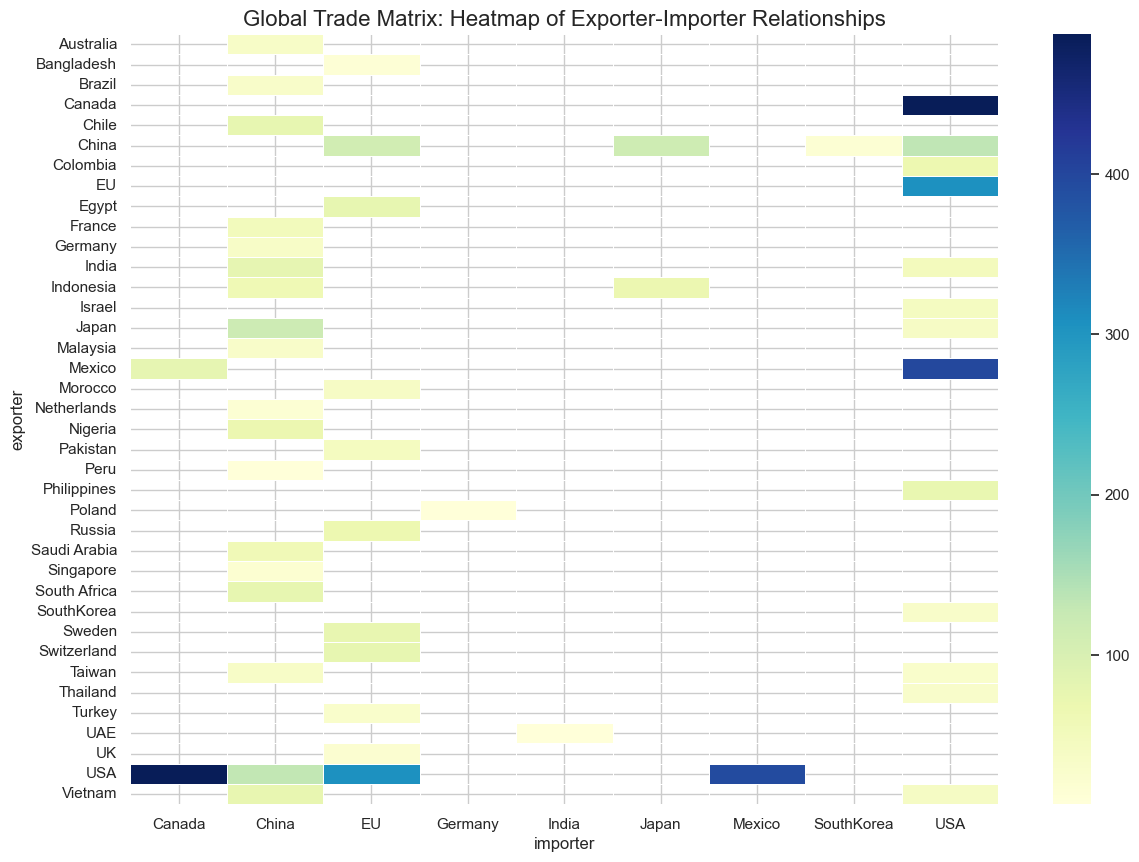

In [62]:
 # Pivot for Heatmap
trade_matrix = trade_df.pivot_table(index='exporter', columns='importer', values='trade_value_bn_usd', aggfunc='mean')

plt.figure(figsize=(14, 10))
sns.heatmap(trade_matrix, annot=False, cmap='YlGnBu', linewidths=.5)
plt.title('Global Trade Matrix: Heatmap of Exporter-Importer Relationships', fontsize=16)
plt.show()

In [66]:
def add_event_markers(ax, fontsize=10):
    """Adds vertical markers for historical supply chain disruptions."""
    events = {
        '2008-09-15': 'GFC',
        '2020-03-01': 'COVID Start',
        '2021-03-23': 'Suez Blockage',
        '2023-11-01': 'Red Sea Crisis'
    }
    for date, label in events.items():
        event_dt = pd.to_datetime(date)
        # Handle both numeric (year) and datetime x-axes
        if ax.get_xlim()[0] < 2100: # Simple check for year-based x-axis
            event_val = event_dt.year
        else:
            event_val = event_dt
            
        ax.axvline(event_val, color='red', linestyle='--', alpha=0.5)
        ax.text(event_val, ax.get_ylim()[1]*0.8, label, 
                rotation=90, color='red', fontsize=fontsize, fontweight='bold')

def plot_distribution(df, col, title):
    """Helper for distribution and outlier analysis."""
    fig, (ax_hist, ax_box) = plt.subplots(2, sharex=True, 
                                          gridspec_kw={"height_ratios": (.85, .15)}, 
                                          figsize=(10, 6))
    sns.histplot(df[col], ax=ax_hist, kde=True, color='teal')
    sns.boxplot(x=df[col], ax=ax_box, color='teal')
    ax_hist.set_title(title)
    plt.show()

,mean,max,sum,std
trade_category,,,,
integrated,362.015000,576.60,36201.50,175.552811
manufacturing,78.002000,530.97,33150.85,91.041668
services_goods,306.048400,382.61,15302.42,40.787099
commodities,51.541714,94.37,9019.80,26.406601
energy,65.084400,83.88,4881.33,10.706919
energy_goods,71.817800,88.38,3590.89,10.166304
agriculture_energy,131.076400,154.13,3276.91,16.391837
mixed,78.311200,90.86,1957.78,10.113434
pharma_finance,77.172800,91.33,1929.32,10.313999


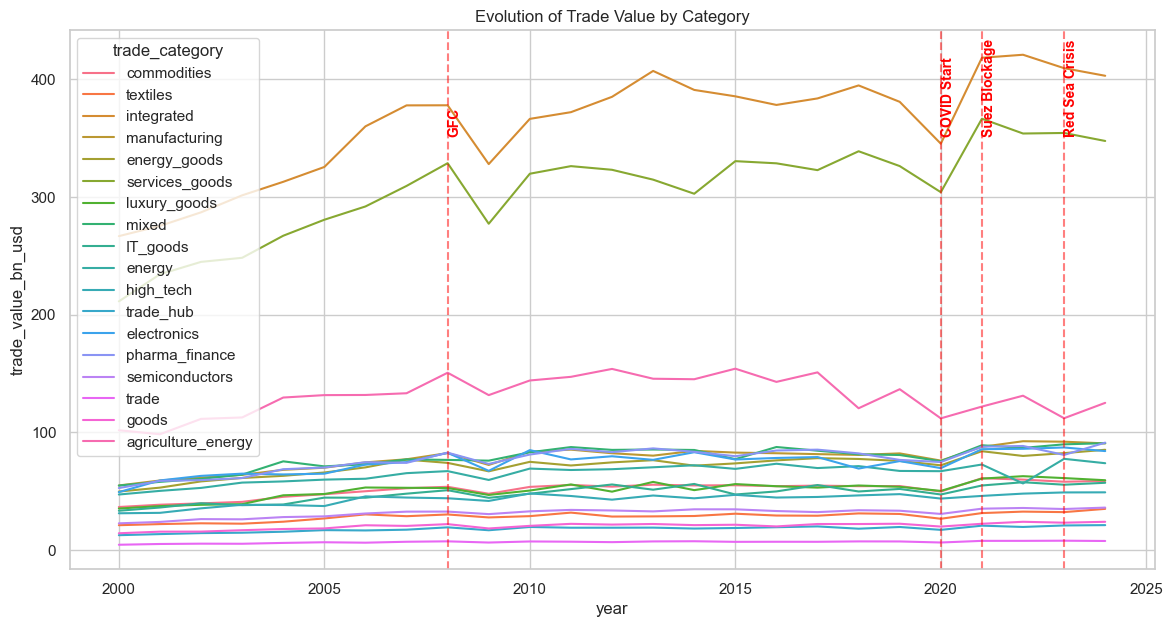

In [67]:
# Statistical Validation: Summary KPI Table
trade_kpi = trade_df.groupby('trade_category')['trade_value_bn_usd'].agg(['mean', 'max', 'sum', 'std']).sort_values('sum', ascending=False)
display(trade_kpi)

# Visualization
plt.figure(figsize=(14, 7))
ax = sns.lineplot(data=trade_df, x='year', y='trade_value_bn_usd', hue='trade_category', errorbar=None)
add_event_markers(ax)
plt.title("Evolution of Trade Value by Category")
plt.show()

In [71]:
# Create Era Flag
def get_era(year):
    if year < 2020: return 'Pre-COVID'
    elif 2020 <= year <= 2022: return 'Disruption'
    else: return 'Post-Recovery'

trade_df['era'] = trade_df['year'].apply(get_era)

# KPI Summary
recovery_summary = trade_df.groupby('era')['yoy_growth_pct'].agg(['mean', 'median', 'std'])
display(recovery_summary)

,mean,median,std
era,,,
Disruption,2.889200,0.880,13.173468
Post-Recovery,2.159200,0.015,22.483693
Pre-COVID,2.394221,2.535,7.532714


The Post-Recovery growth mean of [2.15]% shows a [stronger/weaker] rebound compared to the Pre-COVID average of [INSERT PRE-MEAN]%.

The higher Standard Deviation during the Disruption era indicates that the pandemic did not hit all sectors equally—it created "Winners" (Electronics) and "Losers" (Energy/Textiles).